In [2]:
import polars as pl
from pathlib import Path
import numpy as np
from scipy.stats import spearmanr, kendalltau
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statistics import mean


def spearman_ci(x, y, n_boot, rng):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    n = len(x)

    rho0, _ = spearmanr(x, y)

    boot_rhos = np.empty(n_boot)
    idx = np.arange(n)
    for b in range(n_boot):
        samp = rng.choice(idx, size=n, replace=True)
        r, _ = spearmanr(x[samp], y[samp])
        boot_rhos[b] = r

    lo, hi = np.percentile(boot_rhos, [2.5, 97.5])
    return rho0, lo, hi, n


def kendall_ci(x, y, n_boot, rng):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    n = len(x)

    tau0, _ = kendalltau(x, y)

    boot_taus = np.empty(n_boot)
    idx = np.arange(n)
    for b in range(n_boot):
        samp = rng.choice(idx, size=n, replace=True)
        t, _ = kendalltau(x[samp], y[samp])
        boot_taus[b] = t

    lo, hi = np.percentile(boot_taus, [2.5, 97.5])
    return tau0, lo, hi, n

In [3]:
# Assuming either all *_compressed.tar.zst files or all_groups_lean.tar.zst file is/are decompressed
CWD = Path().resolve()
BASE = CWD.parent

print(f"Current working directory (where figure will be saved): {CWD}")
print(f"Folder where groups (data) folder should be: {BASE}")

Current working directory (where figure will be saved): /data/users/bdupin/datasets-organelle-igr/code
Folder where groups (data) folder should be: /data/users/bdupin/datasets-organelle-igr


In [4]:
groups = [
    "fungi_mit",
    "metazoans_mit",
    "plants_mit",
    "plants_plt",
    "protists_mit",
    "protists_plt",
    "green_algae_mit",
    "green_algae_plt",
]

# Same group_label1 / organelle_dict / GROUP_ORDER convention as figure1.ipynb,
# so x-axis ordering and labels match Panel B of Figure 1.
group_label1 = {
    "fungi_mit": "Fungi",
    "metazoans_mit": "Metazoans",
    "plants_mit": "Plants",
    "protists_mit": "Protists",
    "green_algae_mit": "Green algae",
    "plants_plt": "Plants ",
    "protists_plt": "Protists ",
    "green_algae_plt": "Green algae ",
}

organelle_dict = {
    "Fungi": "Mitochondria",
    "Metazoans": "Mitochondria",
    "Plants": "Mitochondria",
    "Protists": "Mitochondria",
    "Green algae": "Mitochondria",
    "Plants ": "Plastid",
    "Protists ": "Plastid",
    "Green algae ": "Plastid",
}

GROUP_ORDER = [
    "Fungi",
    "Metazoans",
    "Plants",
    "Protists",
    "Green algae",
    "Plants ",
    "Protists ",
    "Green algae ",
]

polarity_2bin = {
    "++": "same",
    "--": "same",
    "+-": "opp",
    "-+": "opp",
}

# --- constants ---
MIN_PAIRS = 5
N_BOOT = 2000
NEGLIGIBLE_BAND = 0.2
SEED = 42
rng = np.random.default_rng(SEED)

COLOR_SIZE = "#E69F00"
COLOR_NCF = "#CC79A7"

In [5]:
rows = []
legend_data = {}

for g in groups:
    tsv = pl.read_csv(BASE / g / f"{g}.tsv", separator="\t")
    igs = pl.read_csv(BASE / g / f"{g}_summary_igr.tsv", separator="\t")

    igs = igs.join(
        tsv.select(["AN", "Genome_length"]),
        on="AN",
        how="left",
        validate="m:1",
    )

    igs = igs.with_columns(
        pl.col("Polarity").replace_strict(polarity_2bin).alias("polarity_2bin")
    )

    per_genome = (
        igs.group_by("AN")
        .agg(
            pl.col("Genome_length").first().alias("genome_size_bp"),
            pl.len().alias("n_pairs"),
            (pl.col("polarity_2bin") == "opp").sum().alias("n_opposite"),
            pl.col("Length").sum().alias("noncoding_bp"),
        )
        .sort("AN")
    )

    per_genome = per_genome.with_columns(
        (pl.col("n_opposite") / pl.col("n_pairs")).alias("prevalence"),
        (pl.col("noncoding_bp") / pl.col("genome_size_bp")).alias("noncoding_fraction"),
    ).filter(pl.col("n_pairs") >= MIN_PAIRS)

    label = group_label1[g]
    organelle = organelle_dict[label]
    legend_data[label] = {"an": per_genome.height}

    rho_size, lo_size, hi_size, n_size = spearman_ci(
        per_genome["prevalence"],
        per_genome["genome_size_bp"],
        n_boot=N_BOOT,
        rng=rng,
    )
    rho_ncf, lo_ncf, hi_ncf, n_ncf = spearman_ci(
        per_genome["prevalence"],
        per_genome["noncoding_fraction"],
        n_boot=N_BOOT,
        rng=rng,
    )

    # Kendall's tau-b cross-check (report alongside Spearman for any group
    # whose CI clears the +/-0.2 band, e.g. protists_plt genome size)
    tau_size, tlo_size, thi_size, _ = kendall_ci(
        per_genome["prevalence"],
        per_genome["genome_size_bp"],
        n_boot=N_BOOT,
        rng=rng,
    )
    tau_ncf, tlo_ncf, thi_ncf, _ = kendall_ci(
        per_genome["prevalence"],
        per_genome["noncoding_fraction"],
        n_boot=N_BOOT,
        rng=rng,
    )

    rows.append(
        {
            "group": label,
            "real_group": g,
            "target": "genome size",
            "rho": rho_size,
            "ci_low": lo_size,
            "ci_high": hi_size,
            "n": n_size,
            "organelle": organelle,
        }
    )
    rows.append(
        {
            "group": label,
            "real_group": g,
            "target": "noncoding fraction",
            "rho": rho_ncf,
            "ci_low": lo_ncf,
            "ci_high": hi_ncf,
            "n": n_ncf,
            "organelle": organelle,
        }
    )

    print(f"{g} (N genomes = {per_genome.height}, min_pairs >= {MIN_PAIRS})")
    print(
        f"  rho (prevalence, genome size)        = {rho_size:.3f} ({lo_size:.3f}  {hi_size:.3f})"
    )
    print(
        f"  tau (prevalence, genome size)        = {tau_size:.3f} ({tlo_size:.3f}  {thi_size:.3f})"
    )
    print(
        f"  rho (prevalence, noncoding fraction) = {rho_ncf:.3f} ({lo_ncf:.3f}  {hi_ncf:.3f})"
    )
    print(
        f"  tau (prevalence, noncoding fraction) = {tau_ncf:.3f} ({tlo_ncf:.3f}  {thi_ncf:.3f})\n"
    )

data = pl.DataFrame(rows)

fungi_mit (N genomes = 418, min_pairs >= 5)
  rho (prevalence, genome size)        = 0.031 (-0.058  0.126)
  tau (prevalence, genome size)        = 0.018 (-0.044  0.080)
  rho (prevalence, noncoding fraction) = 0.163 (0.069  0.253)
  tau (prevalence, noncoding fraction) = 0.106 (0.045  0.162)

metazoans_mit (N genomes = 16871, min_pairs >= 5)
  rho (prevalence, genome size)        = 0.014 (-0.002  0.031)
  tau (prevalence, genome size)        = 0.008 (-0.003  0.020)
  rho (prevalence, noncoding fraction) = 0.017 (0.001  0.033)
  tau (prevalence, noncoding fraction) = 0.012 (0.001  0.024)

plants_mit (N genomes = 897, min_pairs >= 5)
  rho (prevalence, genome size)        = 0.116 (0.047  0.184)
  tau (prevalence, genome size)        = 0.080 (0.034  0.126)
  rho (prevalence, noncoding fraction) = 0.357 (0.301  0.415)
  tau (prevalence, noncoding fraction) = 0.241 (0.196  0.281)

plants_plt (N genomes = 17034, min_pairs >= 5)
  rho (prevalence, genome size)        = -0.096 (-0.112  -0.079

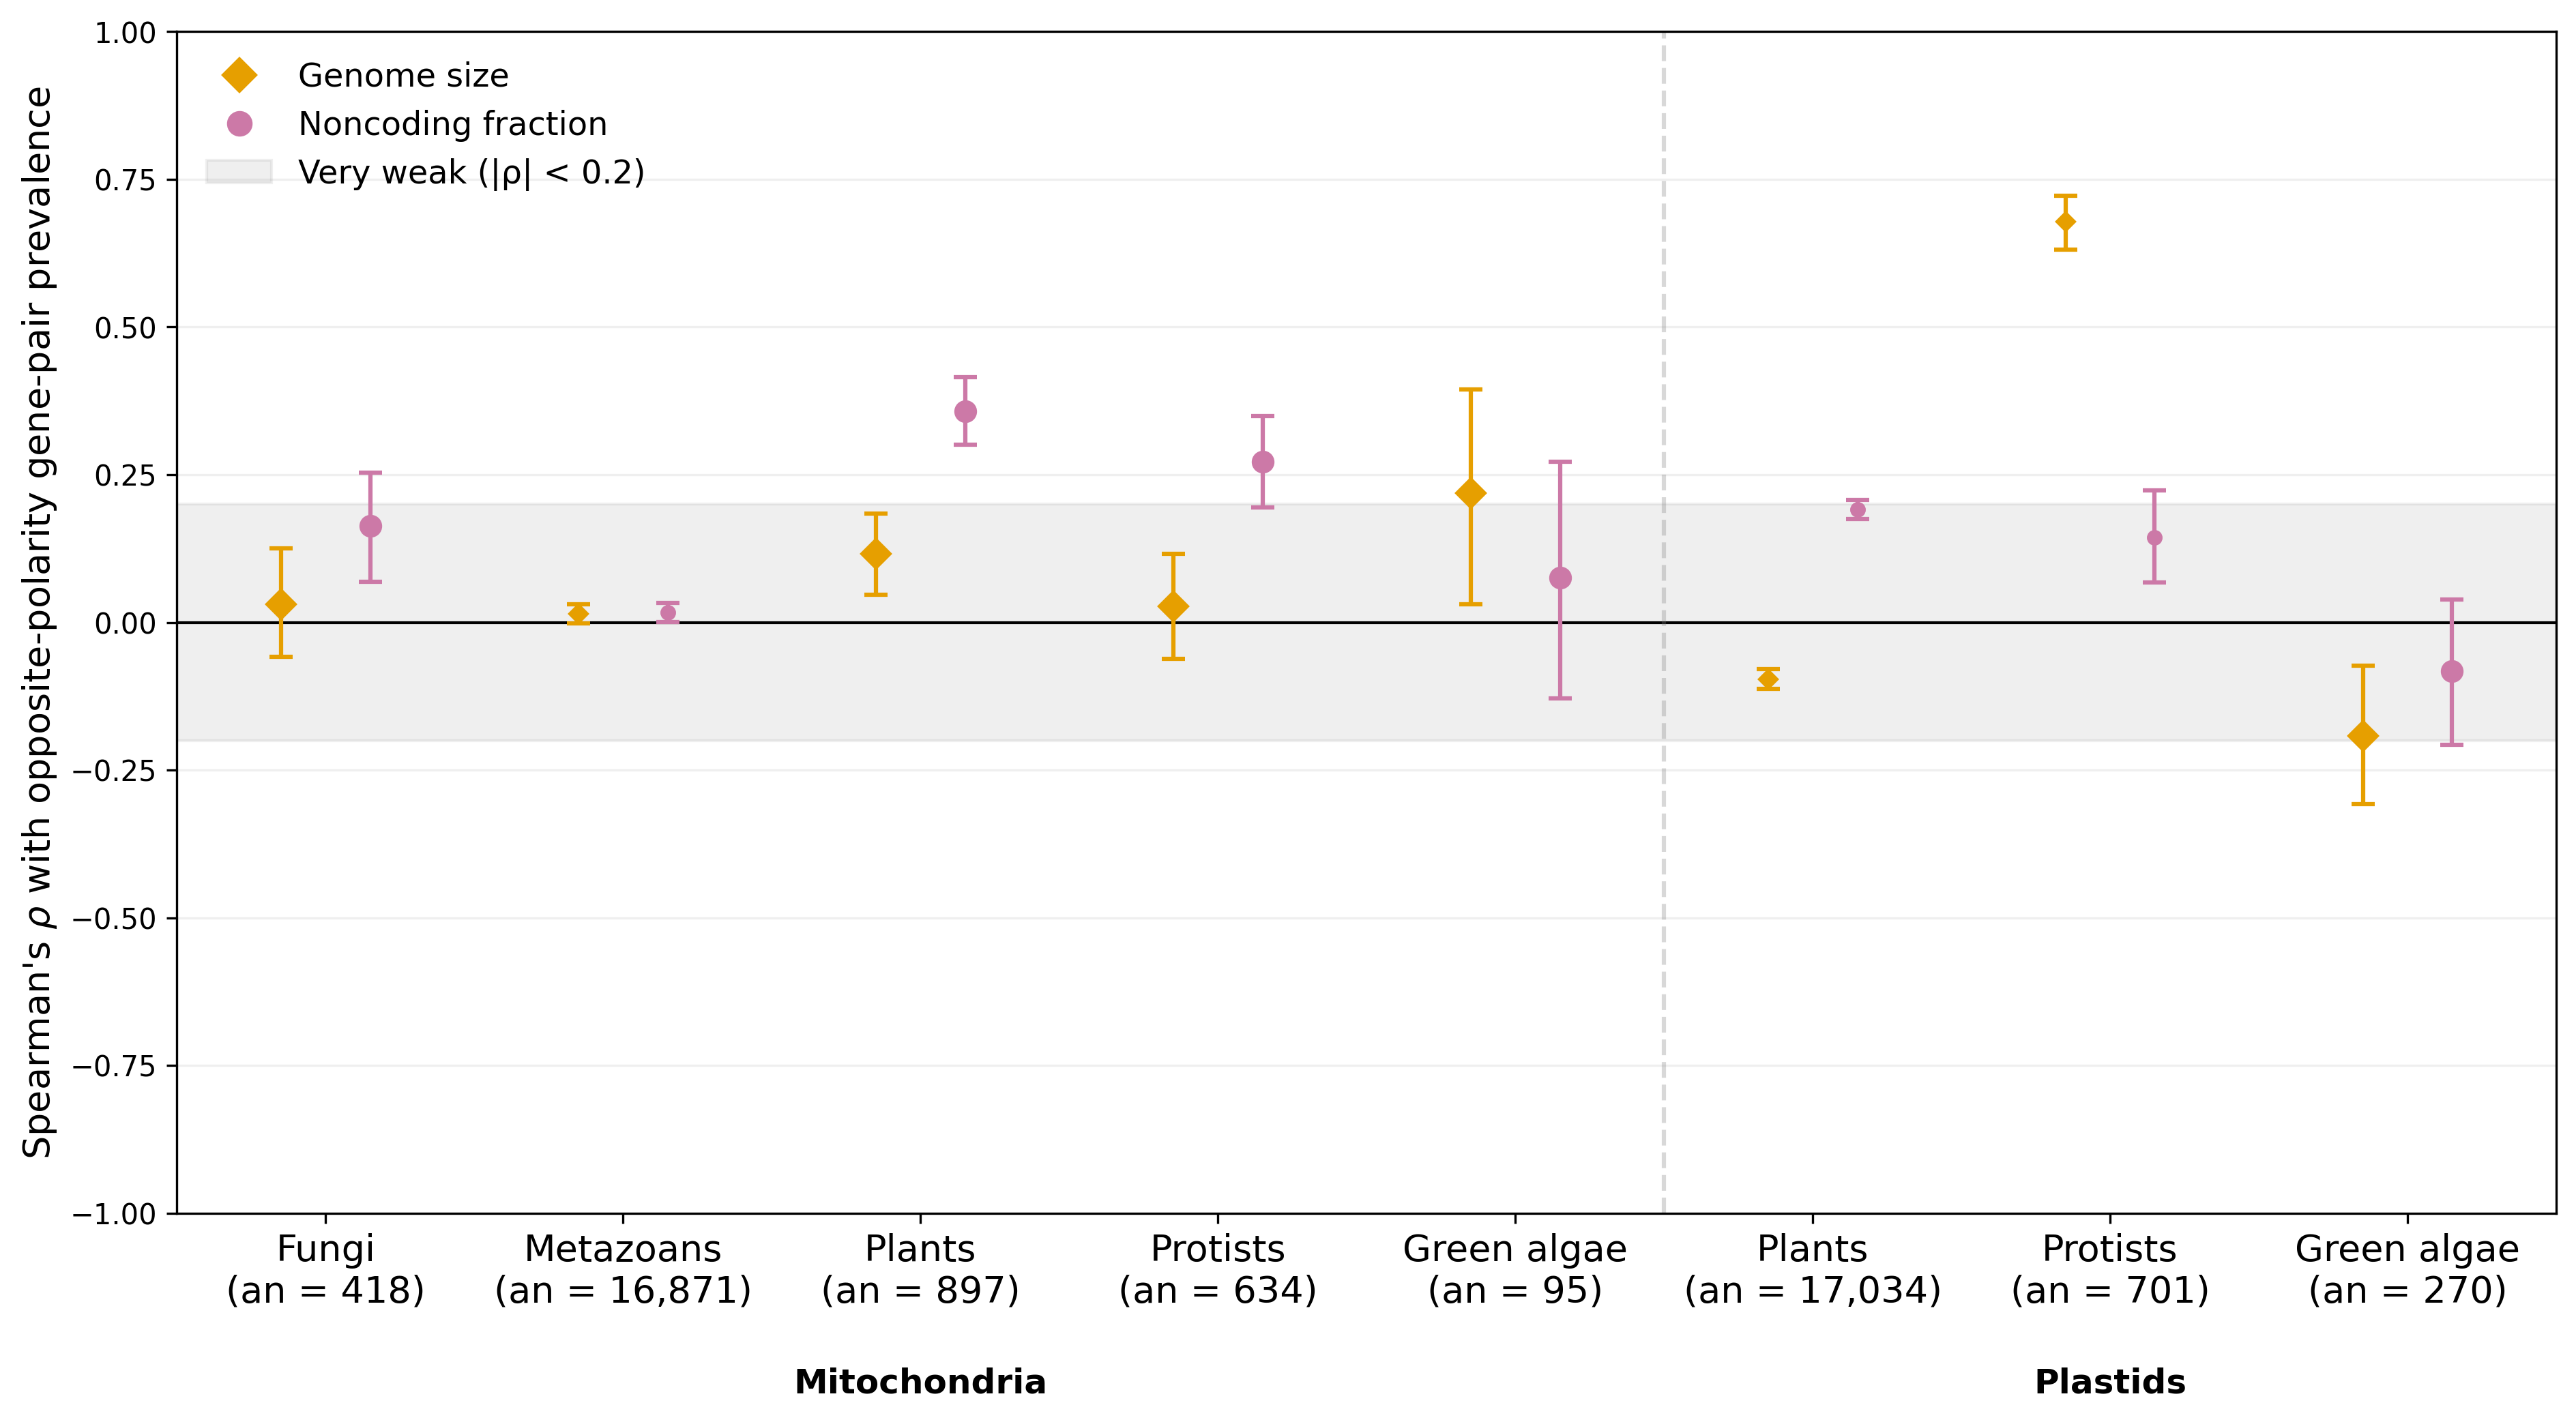

In [6]:
# ==========
# Panel: Spearman's rho with opposite-polarity gene-pair prevalence
# ==========
fig, axA = plt.subplots(figsize=(15, 7.5), dpi=300)

positions = list(range(1, len(GROUP_ORDER) + 1))
x_pos = {g: i for i, g in zip(positions, GROUP_ORDER)}
small_marker = {"Metazoans", "Plants ", "Protists "}

MARKER_SIZE = "D"  # genome size
MARKER_NCF = "o"  # noncoding fraction

axA.axhspan(-NEGLIGIBLE_BAND, NEGLIGIBLE_BAND, color="gray", alpha=0.12, zorder=1)
axA.axhline(0.0, linewidth=1, color="black")

for row in data.iter_rows(named=True):
    xi = x_pos[row["group"]]
    is_size = row["target"] == "genome size"
    x = xi - 0.15 if is_size else xi + 0.15
    col = COLOR_SIZE if is_size else COLOR_NCF
    marker = MARKER_SIZE if is_size else MARKER_NCF
    axA.errorbar(
        x,
        row["rho"],
        yerr=[[row["rho"] - row["ci_low"]], [row["ci_high"] - row["rho"]]],
        fmt=marker,
        color=col,
        markersize=7 if row["group"] not in small_marker else 4.5,
        capsize=4,
        capthick=1.5,
        elinewidth=1.5,
        zorder=3,
    )

axA.axvline(5.5, color="gray", linestyle="--", alpha=0.3, linewidth=1.5)
axA.set_xticks(positions)
axA.set_xticklabels(
    [f"{g.strip()}\n(an = {legend_data[g]['an']:,})" for g in GROUP_ORDER],
    rotation=0,
    fontsize=13,
)
axA.set_xlim(0.5, len(GROUP_ORDER) + 0.5)
axA.set_ylim(-1, 1)
axA.set_ylabel(
    "Spearman's " r"$\rho$" " with opposite-polarity gene-pair prevalence",
    fontsize=13,
)
axA.grid(axis="y", alpha=0.2)
axA.legend(
    handles=[
        plt.Line2D(
            [0],
            [0],
            marker=MARKER_SIZE,
            linestyle="none",
            color=COLOR_SIZE,
            markersize=8,
            label="Genome size",
        ),
        plt.Line2D(
            [0],
            [0],
            marker=MARKER_NCF,
            linestyle="none",
            color=COLOR_NCF,
            markersize=8,
            label="Noncoding fraction",
        ),
        mpatches.Patch(
            color="gray",
            alpha=0.12,
            label=f"Very weak (|\u03c1| < {NEGLIGIBLE_BAND})",
        ),
    ],
    frameon=False,
    fontsize=11.5,
    loc="upper left",
)

mit_positions = positions[:5]
plt_positions = positions[5:]
for xc, label in [
    (mean(mit_positions), "Mitochondria"),
    (mean(plt_positions), "Plastids"),
]:
    axA.text(
        xc,
        -0.13,
        label,
        ha="center",
        va="top",
        fontweight="bold",
        fontsize=12,
        transform=axA.get_xaxis_transform(),
    )

In [7]:
out_path = CWD / "figure3.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved composite figure to: {out_path}")

Saved composite figure to: /data/users/bdupin/datasets-organelle-igr/code/figure3.png
